<a href="https://colab.research.google.com/github/Shinyhunter95/Masters-Project/blob/main/AR(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

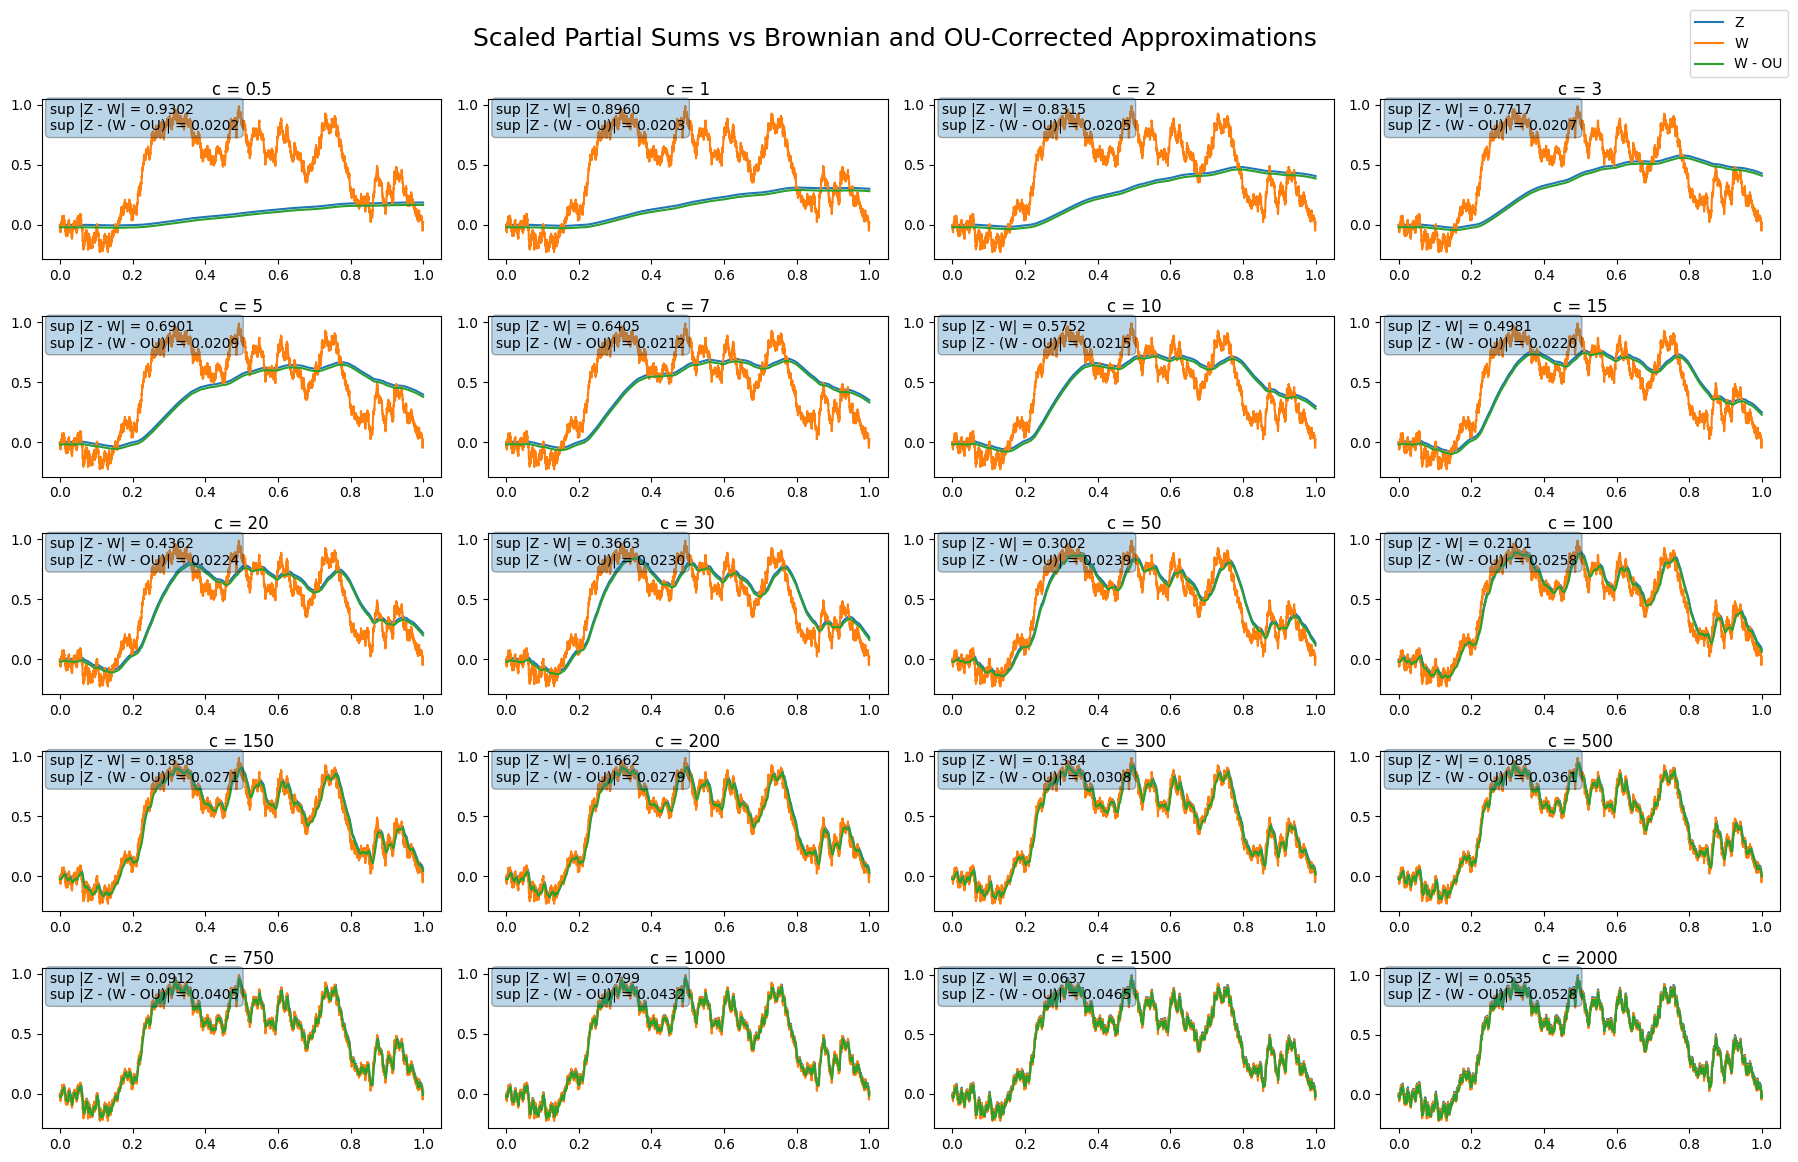

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------
# Parameters
# ---------------------------------

N = 5000
t = np.arange(N) / N
dt = 1 / N

# ---------------------------------
# Random Seed Normal
# ---------------------------------

rng = np.random.default_rng(12345)
eps = rng.standard_normal(N)

# ---------------------------------
# Figure Setup
# ---------------------------------

fig, axes = plt.subplots(5, 4, figsize=(18, 12))
axes = axes.flatten()

# ---------------------------------
# Loop Over c values
# ---------------------------------

c_values = [0.5, 1, 2, 3, 5, 7, 10, 15, 20, 30, 50, 100, 150, 200, 300, 500, 750, 1000, 1500, 2000]

for idx, c in enumerate(c_values):

    rho = 1 - c / N

    # ---------------------------------
    # AR(1) Process
    # ---------------------------------

    U = np.zeros(N)

    for k in range(1, N):
        U[k] = rho * U[k-1] + eps[k]

    # ---------------------------------
    # Partial Sums
    # ---------------------------------

    S = np.cumsum(U)
    Z = (1 - rho) * S / np.sqrt(N)

    # ---------------------------------
    # Brownian Motion
    # ---------------------------------

    dW = eps / np.sqrt(N)
    W = np.cumsum(dW)

    # ---------------------------------
    # OU Correction
    # ---------------------------------

    alpha = np.exp(-c * dt)
    OU_term = np.zeros(N)

    for k in range(1, N):
        OU_term[k] = alpha * OU_term[k-1] + dW[k]

    W_corr = W - OU_term

    # ---------------------------------
    # Errors
    # ---------------------------------

    err_BM = np.max(np.abs(Z - W))
    err_corr = np.max(np.abs(Z - W_corr))

    # ---------------------------------
    # Plot
    # ---------------------------------

    ax = axes[idx]

    fig.suptitle(
        'Scaled Partial Sums vs Brownian and OU-Corrected Approximations',
        fontsize=18, y=.95)

    ax.plot(t, Z, label='Z')
    ax.plot(t, W, label='W')
    ax.plot(t, W_corr, label='W - OU')

    ax.set_title(f'c = {c}', pad=1)

    ax.text(
        0.02,
        0.98,
        (
            f'sup |Z - W| = {err_BM:.4f}\n'
            f'sup |Z - (W - OU)| = {err_corr:.4f}'
       ),
       transform=ax.transAxes,
       verticalalignment='top',
       bbox=dict(boxstyle='round', alpha=0.3)
    )

# ---------------------------------
# Shared Legend
# ---------------------------------

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', ncol=1, bbox_to_anchor=(1, 0.97))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [24]:
print(
    f"{'c':>8} "
    f"{'\u03C1':>10} "
    f"{'sup|Z-W|':>15} "
    f"{'sup|Z-(W-OU)|':>18} "
    f"{'sup|OU|':>15} "
    f"{'Error Reduction':>20}"
)

c_values2 = [0.5, 1, 2, 3, 5, 7, 10, 15, 20, 30, 50, 100, 150, 200, 300, 500, 750, 1000, 1500, 2000, 3000]

for c in c_values2:

    rho = 1 - c / N

    # ---------------------------------
    # AR(1) Process
    # ---------------------------------

    U = np.zeros(N)

    for k in range(1, N):
        U[k] = rho * U[k-1] + eps[k]

    # ---------------------------------
    # Partial Sums
    # ---------------------------------

    S = np.cumsum(U)
    Z = (1 - rho) * S / np.sqrt(N)

    # ---------------------------------
    # Brownian Motion
    # ---------------------------------

    dW = eps / np.sqrt(N)
    W = np.cumsum(dW)

    # ---------------------------------
    # OU Correction
    # ---------------------------------

    alpha = np.exp(-c * dt)
    OU_term = np.zeros(N)

    for k in range(1, N):
        OU_term[k] = alpha * OU_term[k-1] + dW[k]

    W_corr = W - OU_term

    # ---------------------------------
    # Errors
    # ---------------------------------

    err_BM = np.max(np.abs(Z - W))
    err_corr = np.max(np.abs(Z - W_corr))
    sup_OU = np.max(np.abs(OU_term))

    # ---------------------------------
    # Error Reduction Percentage
    # ---------------------------------

    error_reduction = 100 * (1 - err_corr / err_BM)

    # ---------------------------------
    # Print Table
    # ---------------------------------

    print(
        f"{c:8.1f} "
        f"{rho:10.4f} "
        f"{err_BM:15.6f} "
        f"{err_corr:18.6f} "
        f"{sup_OU:15.6f} "
        f"{error_reduction:19.2f}%"
    )

       c          ρ        sup|Z-W|      sup|Z-(W-OU)|         sup|OU|      Error Reduction
     0.5     0.9999        0.930152           0.020233        0.950385               97.82%
     1.0     0.9998        0.896041           0.020326        0.916367               97.73%
     2.0     0.9996        0.831467           0.020502        0.851969               97.53%
     3.0     0.9994        0.771687           0.020663        0.792350               97.32%
     5.0     0.9990        0.690056           0.020944        0.710967               96.96%
     7.0     0.9986        0.640476           0.021178        0.661655               96.69%
    10.0     0.9980        0.575173           0.021533        0.596671               96.26%
    15.0     0.9970        0.498139           0.022009        0.520144               95.58%
    20.0     0.9960        0.436205           0.022409        0.458614               94.86%
    30.0     0.9940        0.366339           0.022994        0.381359          

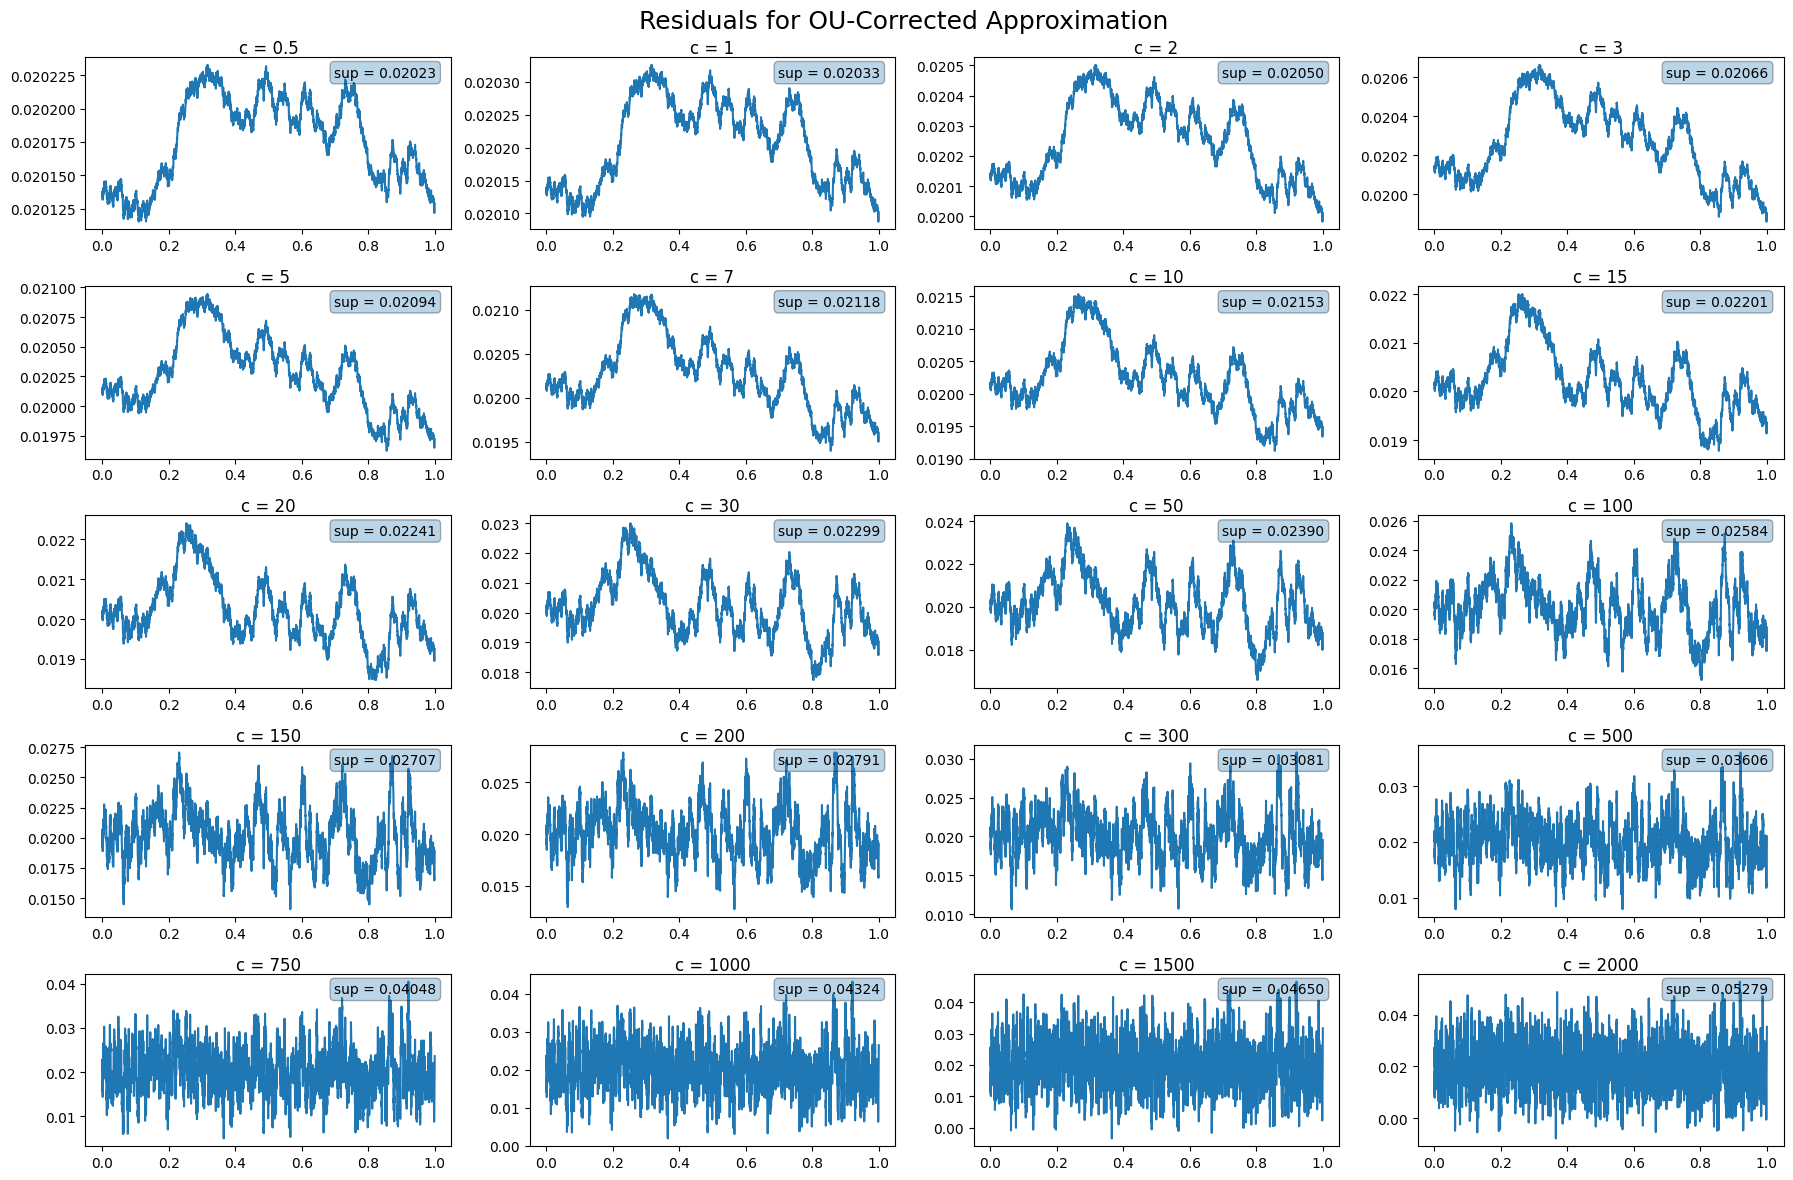

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------
# Parameters
# ---------------------------------

N = 5000
dt = 1 / N
t = np.linspace(0, 1, N)

# ---------------------------------
# Random Seed Normal
# ---------------------------------

rng = np.random.default_rng(12345)
eps = rng.standard_normal(N)

# ---------------------------------
# Figure Setup
# ---------------------------------

fig, axes = plt.subplots(5, 4, figsize=(18, 12))
axes = axes.flatten()

# ---------------------------------
# Loop Over c values
# ---------------------------------

c_values = [0.5, 1, 2, 3, 5, 7, 10, 15, 20, 30, 50, 100, 150, 200, 300, 500, 750, 1000, 1500, 2000]

for idx, c in enumerate(c_values):

    rho = 1 - c / N

    # ---------------------------------
    # AR(1) Process
    # ---------------------------------

    U = np.zeros(N)

    for k in range(1, N):
        U[k] = rho * U[k-1] + eps[k]

    # ---------------------------------
    # Partial Sums
    # ---------------------------------

    S = np.cumsum(U)
    Z = (1 - rho) * S / np.sqrt(N)

    # ---------------------------------
    # Brownian Motion
    # ---------------------------------

    dW = eps / np.sqrt(N)
    W = np.cumsum(dW)

    # ---------------------------------
    # OU Correction
    # ---------------------------------

    alpha = np.exp(-c * dt)
    OU_term = np.zeros(N)

    for k in range(1, N):
        OU_term[k] = alpha * OU_term[k-1] + dW[k]

    W_corr = W - OU_term

    # ---------------------------------
    # Residual
    # ---------------------------------

    residual = Z - W_corr
    sup_residual = np.max(np.abs(residual))

    # ---------------------------------
    # Plot
    # ---------------------------------

    ax = axes[idx]

    fig.suptitle(
    'Residuals for OU-Corrected Approximation',
    fontsize=18
    )
    ax.plot(t, residual)

    # Put text inside the plot
    ax.text(
        0.68,                # x-position in axes coords
        0.95,                # y-position in axes coords
        f'sup = {sup_residual:.5f}',
        transform=ax.transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle='round', alpha=0.3)
    )

    ax.set_title(f'c = {c}', pad=1)

# ---------------------------------
# Layout
# ---------------------------------

plt.tight_layout()
plt.show()

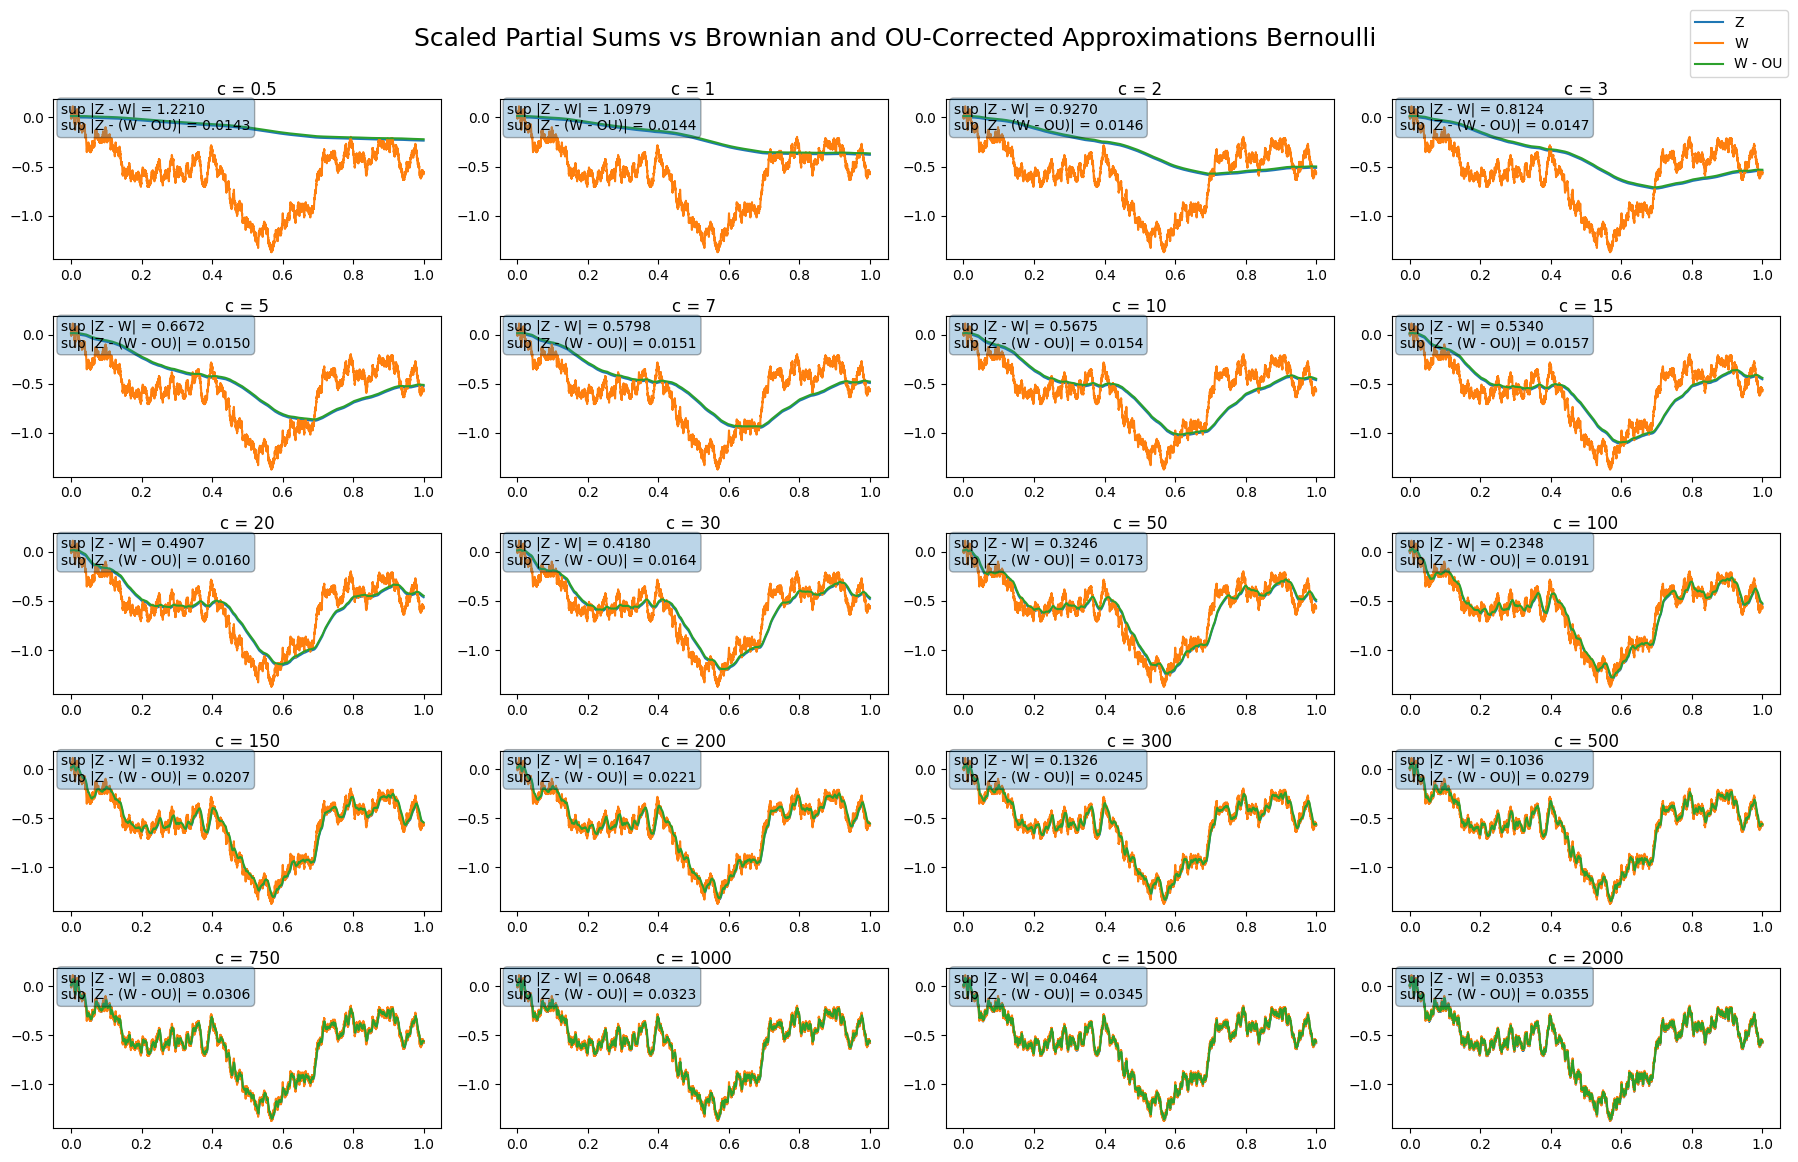

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------
# Parameters
# ---------------------------------

N = 5000
a = 2.0
rho = 1 - a / N
c = N * np.log(1 / rho)
t = np.arange(N) / N
dt = 1 / N

# ---------------------------------
# Random Seed Bernoulli
# ---------------------------------

rng = np.random.default_rng(12345)
eps = rng.choice([-1, 1], size=N)

# ---------------------------------
# Figure Setup
# ---------------------------------

fig, axes = plt.subplots(5, 4, figsize=(18, 12))
axes = axes.flatten()

# ---------------------------------
# Loop Over c values
# ---------------------------------

c_values = [0.5, 1, 2, 3, 5, 7, 10, 15, 20, 30, 50, 100, 150, 200, 300, 500, 750, 1000, 1500, 2000]

for idx, c in enumerate(c_values):

    rho = 1 - c / N

    # ---------------------------------
    # AR(1) Process
    # ---------------------------------

    U = np.zeros(N)

    for k in range(1, N):
        U[k] = rho * U[k-1] + eps[k]

    # ---------------------------------
    # Partial Sums
    # ---------------------------------

    S = np.cumsum(U)
    Z = (1 - rho) * S / np.sqrt(N)

    # ---------------------------------
    # Brownian Motion
    # ---------------------------------

    dW = eps / np.sqrt(N)
    W = np.cumsum(dW)

    # ---------------------------------
    # OU Correction
    # ---------------------------------

    alpha = np.exp(-c * dt)
    OU_term = np.zeros(N)

    for k in range(1, N):
        OU_term[k] = alpha * OU_term[k-1] + dW[k]

    W_corr = W - OU_term

    # ---------------------------------
    # Errors
    # ---------------------------------

    err_BM = np.max(np.abs(Z - W))
    err_corr = np.max(np.abs(Z - W_corr))

    # ---------------------------------
    # Plot
    # ---------------------------------

    ax = axes[idx]
    fig.suptitle(
        'Scaled Partial Sums vs Brownian and OU-Corrected Approximations Bernoulli',
        fontsize=18, y=.95)

    ax.plot(t, Z, label='Z')
    ax.plot(t, W, label='W')
    ax.plot(t, W_corr, label='W - OU')

    ax.set_title(f'c = {c}', pad=1)

    ax.text(
        0.02,
        0.98,
        (
            f'sup |Z - W| = {err_BM:.4f}\n'
            f'sup |Z - (W - OU)| = {err_corr:.4f}'
       ),
       transform=ax.transAxes,
       verticalalignment='top',
       bbox=dict(boxstyle='round', alpha=0.3)
    )

# ---------------------------------
# Shared legend
# ---------------------------------

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', ncol=1, bbox_to_anchor=(1, 0.97))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [28]:
print(
    f"{'c':>8} "
    f"{'\u03C1':>10} "
    f"{'sup|Z-W|':>15} "
    f"{'sup|Z-(W-OU)|':>18} "
    f"{'sup|OU|':>15} "
    f"{'Error Reduction':>20}"
)

c_values2 = [0.5, 1, 2, 3, 5, 7, 10, 15, 20, 30, 50, 100, 150, 200, 300, 500, 750, 1000, 1500, 2000, 3000]

for c in c_values2:

    rho = 1 - c / N

    # ---------------------------------
    # AR(1) Process
    # ---------------------------------

    U = np.zeros(N)

    for k in range(1, N):
        U[k] = rho * U[k-1] + eps[k]

    # ---------------------------------
    # Partial Sums
    # ---------------------------------

    S = np.cumsum(U)
    Z = (1 - rho) * S / np.sqrt(N)

    # ---------------------------------
    # Brownian Motion
    # ---------------------------------

    dW = eps / np.sqrt(N)
    W = np.cumsum(dW)

    # ---------------------------------
    # OU Correction
    # ---------------------------------

    alpha = np.exp(-c * dt)
    OU_term = np.zeros(N)

    for k in range(1, N):
        OU_term[k] = alpha * OU_term[k-1] + dW[k]

    W_corr = W - OU_term

    # ---------------------------------
    # Errors
    # ---------------------------------

    err_BM = np.max(np.abs(Z - W))
    err_corr = np.max(np.abs(Z - W_corr))
    sup_OU = np.max(np.abs(OU_term))

    # ---------------------------------
    # Error Reduction Percentage
    # ---------------------------------

    error_reduction = 100 * (1 - err_corr / err_BM)

    # ---------------------------------
    # Print Table
    # ---------------------------------

    print(
        f"{c:8.1f} "
        f"{rho:10.4f} "
        f"{err_BM:15.6f} "
        f"{err_corr:18.6f} "
        f"{sup_OU:15.6f} "
        f"{error_reduction:19.2f}%"
    )

       c          ρ        sup|Z-W|      sup|Z-(W-OU)|         sup|OU|      Error Reduction
     0.5     0.9999        1.221039           0.014272        1.235311               98.83%
     1.0     0.9998        1.097856           0.014387        1.112242               98.69%
     2.0     0.9996        0.927019           0.014574        0.941592               98.43%
     3.0     0.9994        0.812365           0.014725        0.827091               98.19%
     5.0     0.9990        0.667173           0.014960        0.682133               97.76%
     7.0     0.9986        0.579834           0.015148        0.594982               97.39%
    10.0     0.9980        0.567544           0.015393        0.554540               97.29%
    15.0     0.9970        0.533980           0.015734        0.521593               97.05%
    20.0     0.9960        0.490710           0.015993        0.478815               96.74%
    30.0     0.9940        0.417973           0.016373        0.406819          

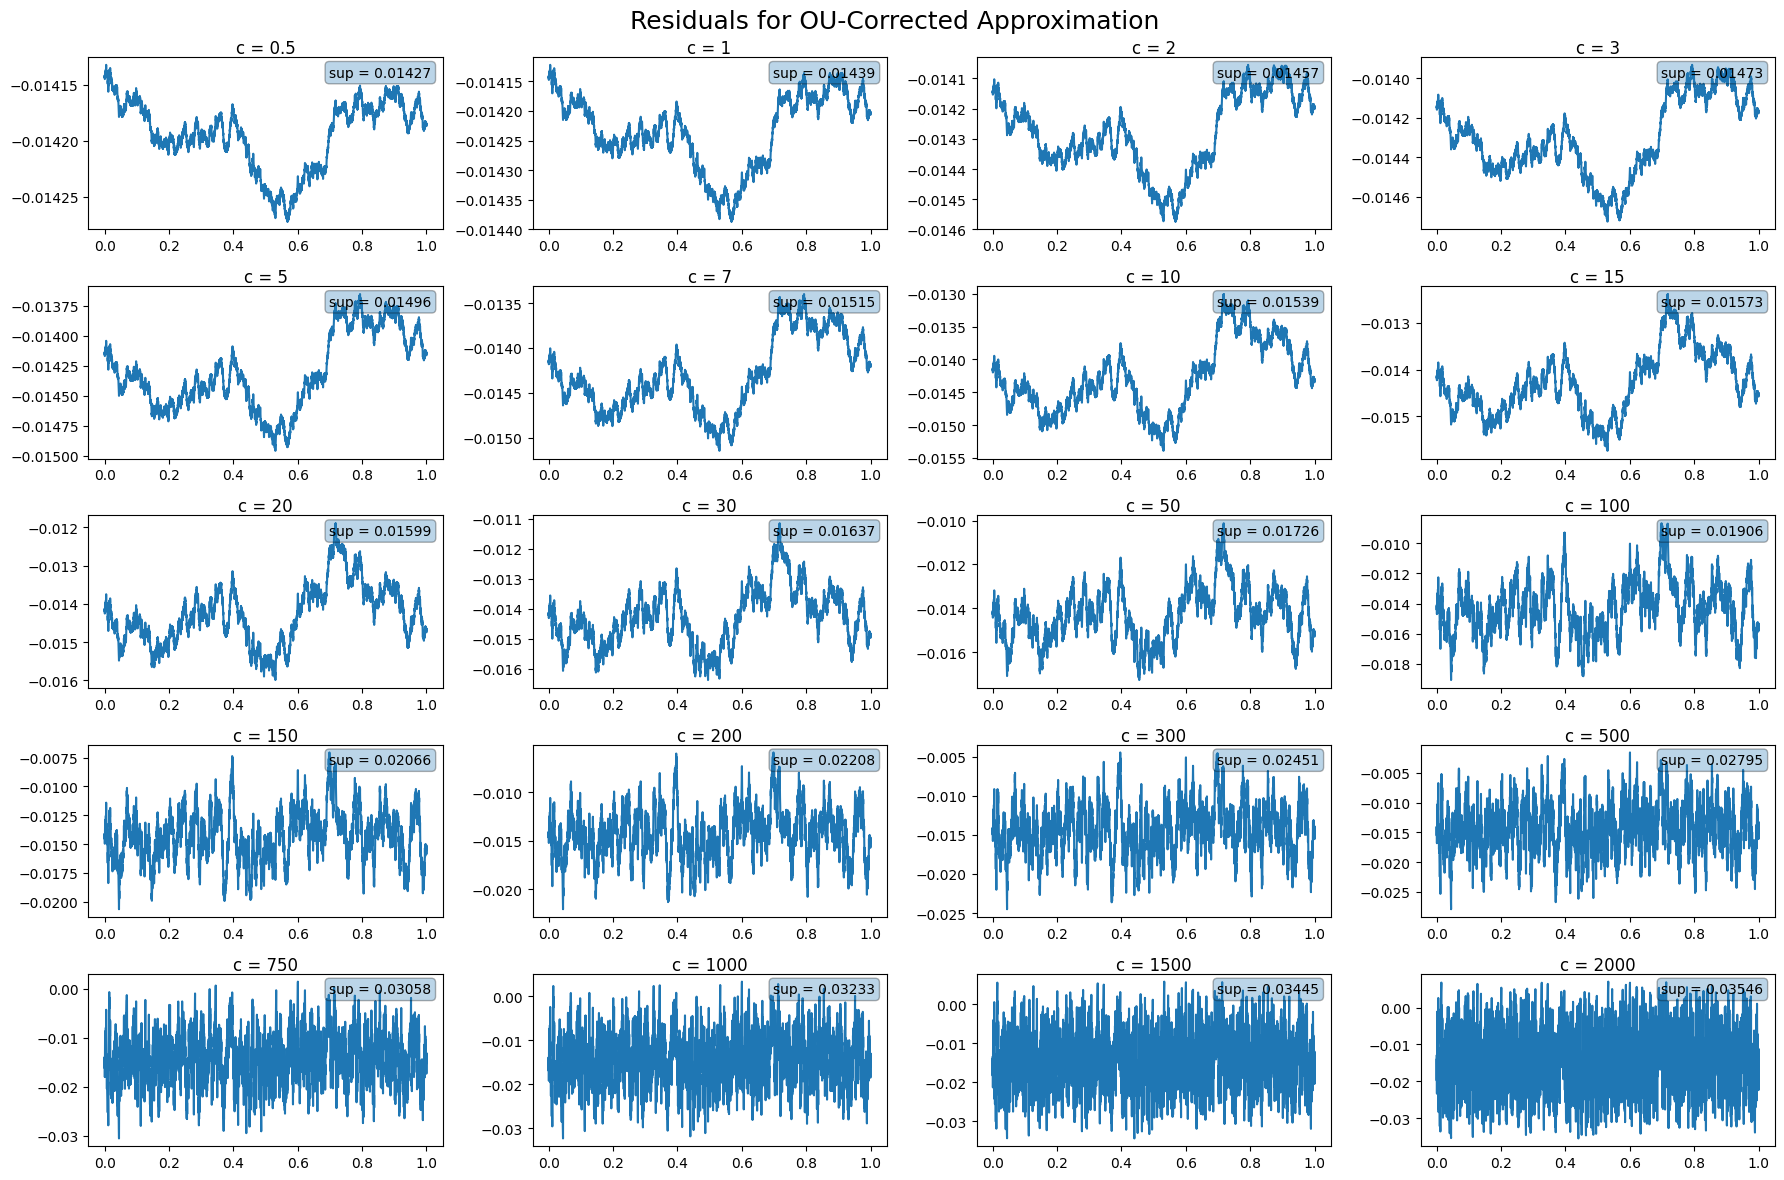

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------
# Parameters
# ---------------------------------

N = 5000
dt = 1 / N
t = np.linspace(0, 1, N)

# ---------------------------------
# Random Seed Bernoulli
# ---------------------------------

rng = np.random.default_rng(12345)
eps = rng.choice([-1, 1], size=N)

# ---------------------------------
# Figure Setup
# ---------------------------------

fig, axes = plt.subplots(5, 4, figsize=(18, 12))
axes = axes.flatten()

# ---------------------------------
# Loop Over c values
# ---------------------------------

c_values = [0.5, 1, 2, 3, 5, 7, 10, 15, 20, 30, 50, 100, 150, 200, 300, 500, 750, 1000, 1500, 2000]

for idx, c in enumerate(c_values):

    rho = 1 - c / N

    # ---------------------------------
    # AR(1) Process
    # ---------------------------------

    U = np.zeros(N)

    for k in range(1, N):
        U[k] = rho * U[k-1] + eps[k]

    # ---------------------------------
    # Partial Sums
    # ---------------------------------

    S = np.cumsum(U)
    Z = (1 - rho) * S / np.sqrt(N)

    # ---------------------------------
    # Brownian Motion
    # ---------------------------------

    dW = eps / np.sqrt(N)
    W = np.cumsum(dW)

    # ---------------------------------
    # OU Correction
    # ---------------------------------

    alpha = np.exp(-c * dt)
    OU_term = np.zeros(N)

    for k in range(1, N):
        OU_term[k] = alpha * OU_term[k-1] + dW[k]

    W_corr = W - OU_term

    # ---------------------------------
    # Residual
    # ---------------------------------

    residual = Z - W_corr
    sup_residual = np.max(np.abs(residual))

    # ---------------------------------
    # Plot
    # ---------------------------------

    ax = axes[idx]
    fig.suptitle(
    'Residuals for OU-Corrected Approximation Bernoulli',
    fontsize=18
    )
    ax.plot(t, residual)

    # Put text inside the plot
    ax.text(
        0.68,                # x-position in axes coords
        0.95,                # y-position in axes coords
        f'sup = {sup_residual:.5f}',
        transform=ax.transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle='round', alpha=0.3)
    )

    ax.set_title(f'c = {c}', pad=1)

# ---------------------------------
# Layout
# ---------------------------------

plt.tight_layout()
plt.show()